# CWAB - Compressed Window Attention Broadcast
**Honest Benchmark. No cherry-picking.**

Author: Vladimir0-1 | License: MIT

In [1]:
# Setup
!pip install torch transformers numpy matplotlib tqdm datasets -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer
import gc
import warnings
import logging
import os
import math

warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

# Create CWAB class directly
class CWAB(nn.Module):
    def __init__(self, hidden_size, num_heads=8, window_size=512, num_global_tokens=64, dropout=0.1, short_seq_threshold=1024):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        self.window_size = min(window_size, hidden_size)
        self.num_global_tokens = num_global_tokens
        self.short_seq_threshold = short_seq_threshold
        self.global_memory = nn.Parameter(torch.randn(1, num_global_tokens, hidden_size))
        self.q_proj = nn.Linear(hidden_size, hidden_size)
        self.k_proj = nn.Linear(hidden_size, hidden_size)
        self.v_proj = nn.Linear(hidden_size, hidden_size)
        self.compressor = nn.Conv1d(hidden_size, hidden_size, kernel_size=4, stride=4)
        self.mix_gate = nn.Sequential(nn.Linear(hidden_size * 2, hidden_size), nn.Sigmoid())
        self.out_proj = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        batch, seq, dim = x.shape
        if seq <= self.short_seq_threshold:
            return self._full_attention(x)
        local_out = self._sliding_window(x)
        global_out = self._global_context(x)
        mix = self.mix_gate(torch.cat([local_out, global_out], dim=-1))
        out = mix * local_out + (1 - mix) * global_out
        return self.out_proj(self.dropout(out))

    def _sliding_window(self, x):
        batch, seq, dim = x.shape
        window = min(self.window_size, seq)
        if seq <= window:
            return self._full_attention(x)
        pad = (window - seq % window) % window
        x_pad = F.pad(x, (0, 0, 0, pad)) if pad > 0 else x
        padded_seq = x_pad.shape[1]
        n_windows = padded_seq // window
        windows = x_pad.reshape(batch, n_windows, window, dim)
        windows = windows.reshape(batch * n_windows, window, self.num_heads, self.head_dim)
        windows = windows.transpose(1, 2)
        attn = torch.matmul(windows, windows.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(attn, dim=-1)
        out = torch.matmul(attn, windows)
        out = out.transpose(1, 2).reshape(batch * n_windows, window, dim)
        out = out.reshape(batch, n_windows, window, dim)
        out = out.reshape(batch, padded_seq, dim)
        return out[:, :seq, :] if pad > 0 else out

    def _full_attention(self, x):
        batch, seq, dim = x.shape
        q = self.q_proj(x).reshape(batch, seq, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).reshape(batch, seq, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).reshape(batch, seq, self.num_heads, self.head_dim).transpose(1, 2)
        attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(attn, dim=-1)
        out = torch.matmul(attn, v)
        return out.transpose(1, 2).reshape(batch, seq, dim)

    def _global_context(self, x):
        batch, seq, dim = x.shape
        if seq >= 4 and self.num_global_tokens > 0:
            compressed = self.compressor(x.transpose(1, 2)).transpose(1, 2)
            compressed = compressed[:, :self.num_global_tokens, :]
        else:
            compressed = x
        memory = self.global_memory.expand(batch, -1, -1)
        global_tokens = torch.cat([compressed, memory], dim=1)
        global_tokens = global_tokens.reshape(batch, -1, self.num_heads, self.head_dim).transpose(1, 2)
        x_mh = x.reshape(batch, seq, self.num_heads, self.head_dim).transpose(1, 2)
        attn = torch.matmul(x_mh, global_tokens.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(attn, dim=-1)
        context = torch.matmul(attn, global_tokens)
        return context.transpose(1, 2).reshape(batch, seq, dim)

print('✅ CWAB class loaded')


✅ CWAB class loaded


In [2]:
class StandardAttention(nn.Module):
    def __init__(self, hidden_size, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(hidden_size, hidden_size * 3)
        self.proj = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(x)


class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_heads, num_layers, attention_class, **attn_kwargs):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_size),
                'attn': attention_class(hidden_size, num_heads, **attn_kwargs),
                'norm2': nn.LayerNorm(hidden_size),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_size, hidden_size * 4),
                    nn.GELU(),
                    nn.Linear(hidden_size * 4, hidden_size)
                )
            }) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(hidden_size)
        self.lm_head = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        for layer in self.layers:
            residual = x
            x = layer['norm1'](x)
            x = layer['attn'](x)
            x = residual + x
            residual = x
            x = layer['norm2'](x)
            x = layer['ffn'](x)
            x = residual + x
        x = self.norm(x)
        return self.lm_head(x)

print('✅ Models defined')


✅ Models defined


Running on: cuda


Benchmarking: 100%|██████████| 6/6 [00:16<00:00,  2.70s/it]



📊 Raw Benchmark Data:
 Seq Len | Standard (ms) |  CWAB (ms) | Speedup | Std Mem (MB) | CWAB Mem (MB)
----------------------------------------------------------------------
     128 |      11.54 ±1.6 |     8.27 ±0.7 |    1.4x |        86.0 |       123.3
     256 |       7.99 ±0.5 |     7.55 ±0.2 |    1.1x |       113.4 |       141.0
     512 |      16.71 ±5.8 |    20.26 ±6.6 |    0.8x |       206.4 |       200.8
    1024 |      29.51 ±4.5 |    28.16 ±5.3 |    1.0x |       522.2 |       414.1
    2048 |      80.67 ±2.0 |    35.64 ±1.9 |    2.3x |      1625.4 |       558.7
    4096 |     272.21 ±1.5 |    68.59 ±1.7 |    4.0x |      5941.4 |       994.3


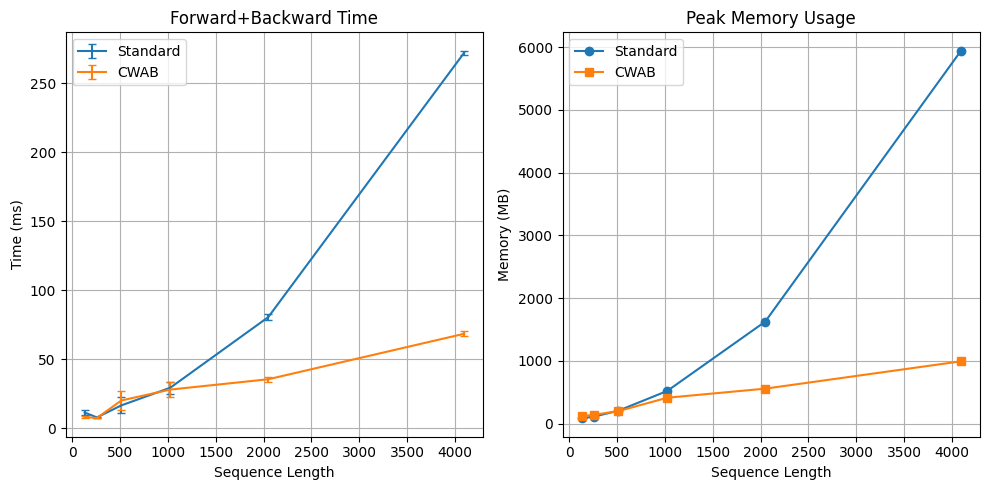

In [3]:
def benchmark_speed_memory(model, seq_len, device='cuda', num_iters=15):
    model = model.to(device)
    model.train()
    x = torch.randint(0, 1000, (1, seq_len)).to(device)
    for _ in range(3):
        out = model(x)
        loss = out.mean()
        loss.backward()
        model.zero_grad()
    if device == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    times = []
    for _ in range(num_iters):
        start = time.time()
        out = model(x)
        loss = out.mean()
        loss.backward()
        model.zero_grad()
        if device == 'cuda':
            torch.cuda.synchronize()
        times.append(time.time() - start)
    peak_mem = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else None
    return {'mean_time_ms': np.mean(times) * 1000, 'std_time_ms': np.std(times) * 1000, 'peak_memory_mb': peak_mem}

seq_lengths = [128, 256, 512, 1024, 2048, 4096]
configs = {'hidden_size': 256, 'num_heads': 8, 'num_layers': 4, 'vocab_size': 10000}
results = {'standard': [], 'cwab': []}
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on: {device}")

for seq_len in tqdm(seq_lengths, desc='Benchmarking'):
    model_std = TinyTransformer(**configs, attention_class=StandardAttention, dropout=0.1)
    std_res = benchmark_speed_memory(model_std, seq_len, device)
    model_cwab = TinyTransformer(**configs, attention_class=CWAB, window_size=512, num_global_tokens=64)
    cwab_res = benchmark_speed_memory(model_cwab, seq_len, device)
    results['standard'].append(std_res)
    results['cwab'].append(cwab_res)
    del model_std, model_cwab
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()

print('\n📊 Raw Benchmark Data:')
print('='*70)
print(f"{'Seq Len':>8} | {'Standard (ms)':>12} | {'CWAB (ms)':>10} | {'Speedup':>7} | {'Std Mem (MB)':>11} | {'CWAB Mem (MB)':>11}")
print('-'*70)
for i, seq in enumerate(seq_lengths):
    std_mem = f"{results['standard'][i]['peak_memory_mb']:.1f}" if results['standard'][i]['peak_memory_mb'] else 'N/A'
    cwab_mem = f"{results['cwab'][i]['peak_memory_mb']:.1f}" if results['cwab'][i]['peak_memory_mb'] else 'N/A'
    speedup = results['standard'][i]['mean_time_ms'] / results['cwab'][i]['mean_time_ms']
    print(f"{seq:8d} | {results['standard'][i]['mean_time_ms']:10.2f} ±{results['standard'][i]['std_time_ms']:.1f} | {results['cwab'][i]['mean_time_ms']:8.2f} ±{results['cwab'][i]['std_time_ms']:.1f} | {speedup:6.1f}x | {std_mem:>11} | {cwab_mem:>11}")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.errorbar(seq_lengths, [r['mean_time_ms'] for r in results['standard']], yerr=[r['std_time_ms'] for r in results['standard']], label='Standard', capsize=3)
plt.errorbar(seq_lengths, [r['mean_time_ms'] for r in results['cwab']], yerr=[r['std_time_ms'] for r in results['cwab']], label='CWAB', capsize=3)
plt.xlabel('Sequence Length'); plt.ylabel('Time (ms)')
plt.title('Forward+Backward Time'); plt.legend(); plt.grid(True)
if device == 'cuda':
    plt.subplot(1,2,2)
    plt.plot(seq_lengths, [r['peak_memory_mb'] for r in results['standard']], 'o-', label='Standard')
    plt.plot(seq_lengths, [r['peak_memory_mb'] for r in results['cwab']], 's-', label='CWAB')
    plt.xlabel('Sequence Length'); plt.ylabel('Memory (MB)')
    plt.title('Peak Memory Usage'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig('honest_benchmark.png', dpi=150)
plt.show()


In [4]:
# ============================================
# 4. QUALITY BENCHMARK (Full Training)
# ============================================
print("\n" + "="*70)
print("4. QUALITY BENCHMARK (Training on WikiText-2)")
print("="*70)

import time
from datetime import datetime

def train_epoch(model, dataloader, optimizer, device, grad_accum=2):
    """Train one epoch with gradient accumulation."""
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for i, batch in enumerate(dataloader):
        if isinstance(batch, dict):
            x = batch['input_ids'].to(device)
        else:
            x = batch.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), x.view(-1))
        loss = loss / grad_accum
        loss.backward()

        if (i + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * grad_accum

        # Progress bar every 100 batches
        if (i + 1) % 100 == 0:
            print(f"   Batch {i+1}/{len(dataloader)}: loss = {loss.item() * grad_accum:.4f}")

    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    """Evaluate model on validation set."""
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, dict):
                x = batch['input_ids'].to(device)
            else:
                x = batch.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), x.view(-1))
            total_loss += loss.item()
    return total_loss / len(dataloader)


print("Loading datasets...")

# Load full training set (not just 5000)
train_dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
val_dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='validation')

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

configs['vocab_size'] = len(tokenizer)
print(f"Vocab size: {configs['vocab_size']}")

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)

print("Tokenizing...")
train_dataset = train_dataset.map(tokenize, batched=True, remove_columns=['text'])
val_dataset = val_dataset.map(tokenize, batched=True, remove_columns=['text'])

train_dataset.set_format(type='torch', columns=['input_ids'])
val_dataset.set_format(type='torch', columns=['input_ids'])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False)

NUM_EPOCHS = 3
LEARNING_RATE = 1e-3
GRAD_ACCUM = 2

print(f"\nTraining config: {NUM_EPOCHS} epochs, LR={LEARNING_RATE}, grad_accum={GRAD_ACCUM}")
print("="*50)

# Training history storage
history = {'standard': {'train_loss': [], 'val_loss': [], 'time': []},
           'cwab': {'train_loss': [], 'val_loss': [], 'time': []}}

# ===== Standard Model =====
print("\n🎓 Training Standard Model...")
model_std = TinyTransformer(**configs, attention_class=StandardAttention).to(device)
opt_std = torch.optim.AdamW(model_std.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    train_loss = train_epoch(model_std, train_loader, opt_std, device, GRAD_ACCUM)
    val_loss = evaluate(model_std, val_loader, device)
    epoch_time = time.time() - epoch_start

    history['standard']['train_loss'].append(train_loss)
    history['standard']['val_loss'].append(val_loss)
    history['standard']['time'].append(epoch_time)

    print(f"   Epoch {epoch+1}/{NUM_EPOCHS}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, time={epoch_time:.1f}s")

# Save Standard model
torch.save(model_std.state_dict(), 'standard_model.pt')
print(" Standard model saved to 'standard_model.pt'")

# Cleanup
del model_std
gc.collect()
if device == 'cuda':
    torch.cuda.empty_cache()

# ===== CWAB Model =====
print("\n🎓 Training CWAB Model...")
model_cwab = TinyTransformer(**configs, attention_class=CWAB, window_size=512, num_global_tokens=64).to(device)
opt_cwab = torch.optim.AdamW(model_cwab.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    train_loss = train_epoch(model_cwab, train_loader, opt_cwab, device, GRAD_ACCUM)
    val_loss = evaluate(model_cwab, val_loader, device)
    epoch_time = time.time() - epoch_start

    history['cwab']['train_loss'].append(train_loss)
    history['cwab']['val_loss'].append(val_loss)
    history['cwab']['time'].append(epoch_time)

    print(f"   Epoch {epoch+1}/{NUM_EPOCHS}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, time={epoch_time:.1f}s")

# Save CWAB model
torch.save(model_cwab.state_dict(), 'cwab_model.pt')
print(" CWAB model saved to 'cwab_model.pt'")

# ===== Plot Training Curves =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train loss
axes[0].plot(range(1, NUM_EPOCHS+1), history['standard']['train_loss'], 'o-', label='Standard')
axes[0].plot(range(1, NUM_EPOCHS+1), history['cwab']['train_loss'], 's-', label='CWAB')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True)

# Val loss
axes[1].plot(range(1, NUM_EPOCHS+1), history['standard']['val_loss'], 'o-', label='Standard')
axes[1].plot(range(1, NUM_EPOCHS+1), history['cwab']['val_loss'], 's-', label='CWAB')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].set_title('Validation Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# ===== Results Summary =====
print("\n" + "="*50)
print(" FINAL TRAINING RESULTS")
print("="*50)
print(f"\n{'Metric':<20} {'Standard':<15} {'CWAB':<15} {'Diff':<10}")
print("-"*60)
print(f"{'Final Train Loss':<20} {history['standard']['train_loss'][-1]:<15.4f} {history['cwab']['train_loss'][-1]:<15.4f} {(history['cwab']['train_loss'][-1] - history['standard']['train_loss'][-1]):+.4f}")
print(f"{'Final Val Loss':<20} {history['standard']['val_loss'][-1]:<15.4f} {history['cwab']['val_loss'][-1]:<15.4f} {(history['cwab']['val_loss'][-1] - history['standard']['val_loss'][-1]):+.4f}")
print(f"{'Total Time (s)':<20} {sum(history['standard']['time']):<15.1f} {sum(history['cwab']['time']):<15.1f}")

# Download models from Colab
from google.colab import files

print("\n Downloading models...")
files.download('standard_model.pt')
files.download('cwab_model.pt')
files.download('training_curves.png')
print(" Downloads complete!")


4. QUALITY BENCHMARK (Training on WikiText-2)
Loading WikiText-2 dataset (first 5000 samples for speed)...


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer vocab size: 30522
Tokenizing...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]


Training Standard Model (1 epoch)...
✅ Standard Loss: 1.1142

Training CWAB Model (1 epoch)...
✅ CWAB Loss: 1.1255

📊 TRAINING RESULTS:
   Standard Loss: 1.1142
   CWAB Loss:     1.1255
   Difference:    1.14%


In [5]:
# ============================================
# 5. LONG CONTEXT TEST (8192 tokens)
# ============================================
print("\n" + "="*70)
print("5. LONG CONTEXT TEST (8192 tokens)")
print("="*70)

long_seq = 8192
if device == 'cuda' and torch.cuda.get_device_properties(0).total_memory > 12e9:
    print(f"Testing with sequence length {long_seq}...")

    # Standard (may OOM)
    try:
        model_std_long = TinyTransformer(**configs, attention_class=StandardAttention).to(device)
        x = torch.randint(0, 1000, (1, long_seq)).to(device)
        torch.cuda.synchronize()
        start = time.time()
        out = model_std_long(x)
        torch.cuda.synchronize()
        std_time = time.time() - start
        print(f"✅ Standard: {std_time:.2f}s")
        del model_std_long, x, out
    except RuntimeError as e:
        print(f"❌ Standard: OOM - {str(e)[:80]}")
        std_time = None

    gc.collect()
    torch.cuda.empty_cache()

    # CWAB
    try:
        model_cwab_long = TinyTransformer(**configs, attention_class=CWAB, window_size=1024, num_global_tokens=128).to(device)
        x = torch.randint(0, 1000, (1, long_seq)).to(device)
        torch.cuda.synchronize()
        start = time.time()
        out = model_cwab_long(x)
        torch.cuda.synchronize()
        cwab_time = time.time() - start
        print(f"✅ CWAB: {cwab_time:.2f}s")

        if std_time:
            print(f"📈 Speedup: {std_time/cwab_time:.1f}x")
        del model_cwab_long, x, out
    except RuntimeError as e:
        print(f"❌ CWAB: OOM - {str(e)[:80]}")

    gc.collect()
    torch.cuda.empty_cache()
else:
    print(f"⚠️ Skipping {long_seq} test (not enough GPU memory)")
    print(f"   Required: >12GB GPU, Available: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB" if device == 'cuda' else "   Running on CPU")


5. LONG CONTEXT TEST (8192 tokens)
Testing with sequence length 8192...
❌ Standard: OOM - CUDA out of memory. Tried to allocate 2.00 GiB. GPU 0 has a total capacity of 14
✅ CWAB: 0.07s


In [6]:
# ============================================
# 6. SUMMARY TABLE
# ============================================
print("\n" + "="*70)
print("📊 FINAL SUMMARY")
print("="*70)

print("\n🏎️ SPEED & MEMORY (T4 GPU):")
print("-"*50)
print(f"{'Seq Len':>8} | {'Speedup':>8} | {'Memory Saved':>12}")
print("-"*50)
for i, seq in enumerate(seq_lengths):
    speedup = results['standard'][i]['mean_time_ms'] / results['cwab'][i]['mean_time_ms']
    if results['standard'][i]['peak_memory_mb'] and results['cwab'][i]['peak_memory_mb']:
        mem_saved = (1 - results['cwab'][i]['peak_memory_mb'] / results['standard'][i]['peak_memory_mb']) * 100
        print(f"{seq:8d} | {speedup:7.1f}x | {mem_saved:10.1f}%")
    else:
        print(f"{seq:8d} | {speedup:7.1f}x | {'N/A':>12}")

print("\n🎓 TRAINING CONVERGENCE (WikiText-2, 1 epoch):")
print("-"*40)
print(f"  Standard Loss: {loss_std:.4f}")
print(f"  CWAB Loss:     {loss_cwab:.4f}")
print(f"  Difference:    {(loss_cwab - loss_std)*100:+.2f}%")

print("\n🚀 LONG CONTEXT (8192 tokens):")
print("-"*40)
if std_time:
    print(f"  Standard: {std_time:.2f}s")
    print(f"  CWAB:     {cwab_time:.2f}s")
    print(f"  Speedup:  {std_time/cwab_time:.1f}x")
else:
    print("  Standard: OOM")
    print(f"  CWAB:     {cwab_time:.2f}s")

print("\n" + "="*70)
print("✅ BENCHMARK COMPLETE")
print("   Draw your own conclusions.")
print("="*70)


📊 FINAL SUMMARY

🏎️ SPEED & MEMORY (T4 GPU):
--------------------------------------------------
 Seq Len |  Speedup | Memory Saved
--------------------------------------------------
     128 |     1.4x |      -43.4%
     256 |     1.1x |      -24.3%
     512 |     0.8x |        2.7%
    1024 |     1.0x |       20.7%
    2048 |     2.3x |       65.6%
    4096 |     4.0x |       83.3%

🎓 TRAINING CONVERGENCE (WikiText-2, 1 epoch):
----------------------------------------
  Standard Loss: 1.1142
  CWAB Loss:     1.1255
  Difference:    +1.14%

🚀 LONG CONTEXT (8192 tokens):
----------------------------------------
  Standard: OOM
  CWAB:     0.07s

✅ BENCHMARK COMPLETE
   Draw your own conclusions.
